# Held-out validation of the allometric height model — `ovgu_bbox`

**The loop built here, entirely inside the Baumkataster:**

> split the `ovgu_bbox` registry trees into train and test → fit A, B on **train** →
> estimate heights on **test** from `CPA = π(Kronendurchmesser/2)²` → score against `Baumhoehe`
> on those same test trees.


In [1]:
import sys
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.lines import Line2D
from shapely.geometry import box
from pyproj import Transformer
from sklearn.model_selection import KFold, train_test_split

ROOT = Path.cwd().parent if Path.cwd().name == "test_notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

from src.config import ALLOMETRIC_A, ALLOMETRIC_B, AREAS
from src.shadow.allometry import (
    BK_FIT_FILTER, bk_crown_area, fit_allometry, label_landuse,
    noise_ceiling, predict_height, score, smearing_factor,
)

AREA         = "ovgu_bbox"
REGISTRY     = ROOT / "references" / "Baeume_SFM_2026.gpkg"
PARK_NAME    = "Nordpark"          # matched against Objektbezeichnung
TEST_SIZE    = 0.30
N_FOLDS      = 5
RANDOM_STATE = 42

pd.set_option("display.width", 200)
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")

## 1 · The population

Registry trees inside the `ovgu_bbox` extent, filtered with the **same** `BK_FIT_FILTER` that
produced the citywide n=84,081 fit — so every number below stays comparable to the quoted 0.531.

The park/street label comes from `Objektart lang` and needs no OSM fetch: `AMT 66` is the road
authority, and 30,231 of its 30,410 citywide rows carry `/SBG` (*Straßenbegleitgrün*) while no
`Öffentliches Grün` row does. `src/data_preprocessing/osm.py` only ever pulls `building` and `highway`.

In [2]:
bk = gpd.read_file(REGISTRY).query(BK_FIT_FILTER)

_t = Transformer.from_crs("EPSG:4326", "EPSG:25832", always_xy=True)
_a = AREAS[AREA]
_w, _s = _t.transform(_a["west"], _a["south"])
_e, _n = _t.transform(_a["east"], _a["north"])

trees = bk[bk.geometry.within(box(_w, _s, _e, _n))].copy().reset_index(drop=True)

trees["cpa_m2"]  = bk_crown_area(trees["Kronendurchmesser"])
trees["landuse"] = label_landuse(trees)
trees["is_park"] = trees["Objektbezeichnung"].fillna("").str.contains(PARK_NAME)
# Three strata for reporting only. The large park is kept separate from the remaining green
# so that per-stratum accuracy is not dominated by it -- no split is defined on these labels.
trees["stratum"] = np.where(trees["is_park"], "park",
                     np.where(trees["landuse"] == "street", "street", "other green"))

print(f"{AREA}: {len(trees)} usable registry trees  (filter: {BK_FIT_FILTER})")
print(f"  area {(_e - _w):.0f} x {(_n - _s):.0f} m,  CRS {trees.crs.to_string()}\n")
print(trees.groupby("stratum").agg(
    n=("Baumhoehe", "size"),
    median_h_m=("Baumhoehe", "median"),
    median_crown_d_m=("Kronendurchmesser", "median"),
    median_cpa_m2=("cpa_m2", "median"),
).to_string())

ovgu_bbox: 1045 usable registry trees  (filter: Baumhoehe > 1 and Kronendurchmesser > 0.5)
  area 855 x 908 m,  CRS EPSG:25832

               n  median_h_m  median_crown_d_m  median_cpa_m2
stratum                                                      
other green   95      15.000             8.000         50.265
park         602      15.000             9.000         63.617
street       348       8.000             6.000         28.274


The bbox is one neighbourhood out of a city-wide registry, and the coefficients in `config.py` were
fitted on all of it. So the question that decides how far these results travel is whether this
neighbourhood is **representative** — if its trees are systematically larger or taller than the city
as a whole, a locally-fitted model is describing local trees, not Magdeburg trees.

In [3]:
city = bk.copy()
city["cpa_m2"]  = bk_crown_area(city["Kronendurchmesser"])
city["landuse"] = label_landuse(city)

def _profile(df, tag):
    out = {}
    for grp, d in [("all", df)] + sorted(df.groupby("landuse"), key=lambda kv: kv[0]):
        out[(grp, tag)] = {
            "n": len(d),
            "median_h_m": d["Baumhoehe"].median(),
            "median_crown_d_m": d["Kronendurchmesser"].median(),
            "median_cpa_m2": d["cpa_m2"].median(),
        }
    return out

prof = {**_profile(city, "city"), **_profile(trees, AREA)}
cmp_tbl = (pd.DataFrame(prof).T
             .rename_axis(index=["land use", "population"])
             .unstack()
             .swaplevel(axis=1)
             .sort_index(axis=1, level=0, ascending=False))
cmp_tbl[("city", "n")] = cmp_tbl[("city", "n")].astype(int)
cmp_tbl[(AREA, "n")]   = cmp_tbl[(AREA, "n")].astype(int)
print(cmp_tbl.to_string())

print(f"\n{AREA} holds {len(trees) / len(city) * 100:.1f}% of the {len(city):,} usable registry trees citywide.")
for k in ("all", "green", "street"):
    dh = prof[(k, AREA)]["median_h_m"] - prof[(k, "city")]["median_h_m"]
    dd = prof[(k, AREA)]["median_crown_d_m"] - prof[(k, "city")]["median_crown_d_m"]
    print(f"  {k:<7} median height {dh:+.1f} m, median crown diameter {dd:+.1f} m vs the city")

population ovgu_bbox                                             city                                          
                   n median_h_m median_crown_d_m median_cpa_m2      n median_h_m median_crown_d_m median_cpa_m2
land use                                                                                                       
all             1045     12.000            8.000        50.265  84081     11.000            6.000        28.274
green            696     15.000            9.000        63.617  53947     12.000            6.000        28.274
street           349      8.000            6.000        28.274  30134      9.000            6.000        28.274

ovgu_bbox holds 1.2% of the 84,081 usable registry trees citywide.
  all     median height +1.0 m, median crown diameter +2.0 m vs the city
  green   median height +3.0 m, median crown diameter +3.0 m vs the city
  street  median height -1.0 m, median crown diameter +0.0 m vs the city


## 2 · Split A — a plain 70/30 train/test split

Stratified by park / street / other green so the test set keeps the same composition as the whole,
which matters here because one park is 58 % of the data.

Fit on train, estimate heights on test, score against the test trees' own `Baumhoehe`.

In [4]:
train, test = train_test_split(
    trees, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=trees["stratum"]
)
assert not (set(train.index) & set(test.index)), "train/test overlap"

A, B, n_fit = fit_allometry(train["cpa_m2"], train["Baumhoehe"])
base = train["Baumhoehe"].mean()          # fixed baseline, from TRAIN only
print(f"train n={n_fit}  ->  A={A:.3f}  B={B:.3f}    (config: A={ALLOMETRIC_A}, B={ALLOMETRIC_B})")
print(f"train mean height = {base:.2f} m   Duan smearing factor = {smearing_factor(train['cpa_m2'], train['Baumhoehe'], A, B):.4f}")
print("  (smearing would convert the median predictor to a mean predictor -- reported, not applied)\n")

rows = [{"subset": "TEST all", **score(test["Baumhoehe"], predict_height(test["cpa_m2"], A, B), base)}]
for k, d in test.groupby("stratum"):
    rows.append({"subset": f"TEST {k}", **score(d["Baumhoehe"], predict_height(d["cpa_m2"], A, B), base)})
split_a = pd.DataFrame(rows).set_index("subset")
print(split_a.to_string())

train n=731  ->  A=1.181  B=0.349    (config: A=1.317, B=0.318)
train mean height = 13.13 m   Duan smearing factor = 1.0488
  (smearing would convert the median predictor to a mean predictor -- reported, not applied)

                    n  bias_m  MAE_m  RMSE_m  r2_ln  r2_m  median_ratio
subset                                                                 
TEST all          314  -0.486  3.252   4.285  0.651 0.582         1.055
TEST other green   28  -0.578  2.926   3.393  0.409 0.379         0.995
TEST park         181  -1.139  3.583   4.847  0.666 0.553         0.969
TEST street       105   0.663  2.770   3.366  0.535 0.684         1.150


## 3 · Split B — 5-fold cross-validation  ·  **the headline**

Every tree gets a prediction from a model that never saw it, so all 1,045 are scored out-of-fold
rather than only the 314 in Split A's test set.

The per-fold coefficient table is the check that matters: if A and B swing wildly across folds, a
single 70/30 split was luck. If they are stable, the model is identified by this data.

In [5]:
kf = KFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)
oof = np.full(len(trees), np.nan)
fold_rows = []

for i, (itr, ite) in enumerate(kf.split(trees), start=1):
    assert not (set(itr) & set(ite)), f"fold {i}: train/test overlap"
    a, b, n = fit_allometry(trees["cpa_m2"].iloc[itr], trees["Baumhoehe"].iloc[itr])
    oof[ite] = predict_height(trees["cpa_m2"].iloc[ite], a, b)
    fold_rows.append({"fold": i, "n_train": n, "n_test": len(ite), "A": a, "B": b})

assert not np.isnan(oof).any(), "some tree never received an out-of-fold prediction"
print(pd.DataFrame(fold_rows).set_index("fold").to_string())
print(f"\nA spread: {min(r['A'] for r in fold_rows):.3f} - {max(r['A'] for r in fold_rows):.3f}"
      f"   B spread: {min(r['B'] for r in fold_rows):.3f} - {max(r['B'] for r in fold_rows):.3f}")

      n_train  n_test     A     B
fold                             
1         836     209 1.174 0.351
2         836     209 1.199 0.343
3         836     209 1.185 0.348
4         836     209 1.128 0.358
5         836     209 1.154 0.352

A spread: 1.128 - 1.199   B spread: 0.343 - 0.358


In [6]:
base_all = trees["Baumhoehe"].mean()
rows = [{"subset": "pooled OOF", **score(trees["Baumhoehe"], oof, base_all)}]
for k, idx in trees.groupby("stratum").groups.items():
    rows.append({"subset": f"OOF {k}", **score(trees.loc[idx, "Baumhoehe"], oof[trees.index.get_indexer(idx)], base_all)})
split_b = pd.DataFrame(rows).set_index("subset")
print(split_b.to_string())

                    n  bias_m  MAE_m  RMSE_m  r2_ln  r2_m  median_ratio
subset                                                                 
pooled OOF       1045  -0.624  3.066   4.044  0.661 0.604         1.006
OOF other green    95  -0.130  2.563   3.100  0.623 0.564         1.037
OOF park          602  -1.307  3.330   4.482  0.676 0.588         0.935
OOF street        348   0.424  2.746   3.426  0.531 0.650         1.144


## 4 · Error in metres, by how tall the tree actually is

R² is a single number over a population; it does not say *how wrong the height is*, which is what
the shadow model downstream consumes. Shadow length scales as `height / tan(sun elevation)`, so a
metre of height error is a metre-scale error in the cast shadow.

Binning the out-of-fold predictions by **observed** height gives the decision-relevant view.

In [7]:
oof_df = trees[["Baumhoehe", "stratum"]].copy()
oof_df["pred_m"] = oof
oof_df["err_m"]  = oof_df["pred_m"] - oof_df["Baumhoehe"]
oof_df["abs_pct"] = (oof_df["err_m"] / oof_df["Baumhoehe"]).abs() * 100

BANDS = [0, 6, 10, 14, 18, 22, 40]
oof_df["band"] = pd.cut(oof_df["Baumhoehe"], BANDS, right=False)

by_band = oof_df.groupby("band", observed=True).agg(
    n=("err_m", "size"),
    median_observed_m=("Baumhoehe", "median"),
    median_predicted_m=("pred_m", "median"),
    bias_m=("err_m", "mean"),
    MAE_m=("err_m", lambda s: s.abs().mean()),
    median_abs_pct=("abs_pct", "median"),
)
print(by_band.to_string())

tall = oof_df[oof_df["Baumhoehe"] >= 22]
print(f"\nPredictions span {oof_df['pred_m'].min():.1f}-{oof_df['pred_m'].max():.1f} m; "
      f"observations span {oof_df['Baumhoehe'].min():.0f}-{oof_df['Baumhoehe'].max():.0f} m.")
print(f"Trees >= 22 m (n={len(tall)}) are under-predicted by {-tall['err_m'].mean():.1f} m on average,")
print(f"which shortens their modelled shadow by about {100 * -tall['err_m'].mean() / tall['Baumhoehe'].mean():.0f}%.")

            n  median_observed_m  median_predicted_m  bias_m  MAE_m  median_abs_pct
band                                                                               
[0, 6)    107              4.000               5.555   1.141  1.803          29.145
[6, 10)   290              8.000               9.223   2.037  2.356          30.522
[10, 14)  160             12.000              12.580   0.814  2.128          15.354
[14, 18)  196             16.000              13.882  -1.205  2.745          16.516
[18, 22)  159             20.000              15.973  -2.670  3.692          18.016
[22, 40)  133             24.000              17.940  -6.271  6.482          23.725

Predictions span 2.8-29.2 m; observations span 3-30 m.
Trees >= 22 m (n=133) are under-predicted by 6.3 m on average,
which shortens their modelled shadow by about 26%.


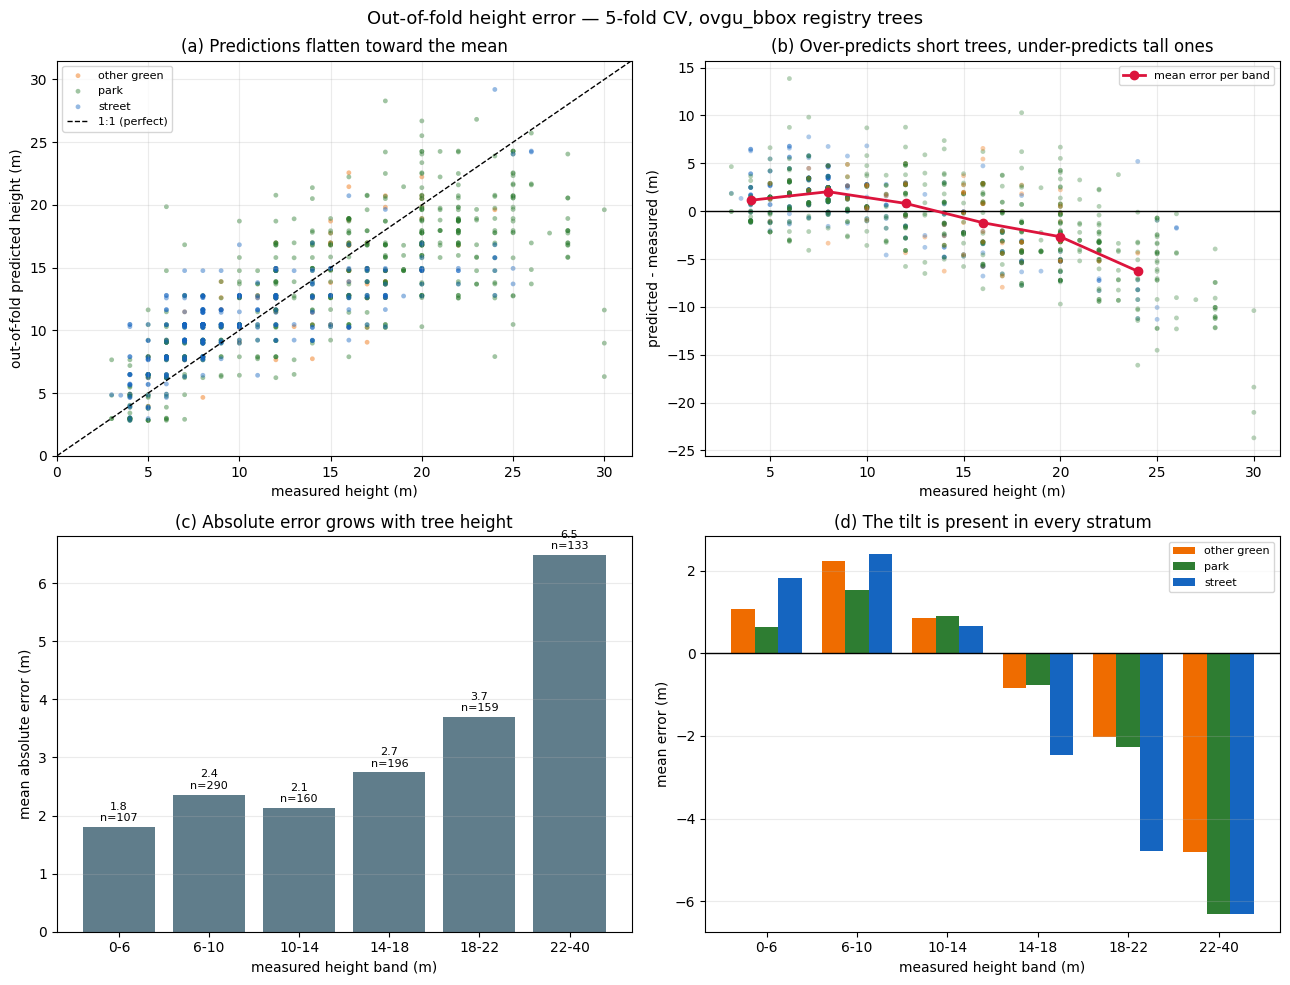

In [8]:
fig, ax = plt.subplots(2, 2, figsize=(13, 10))
COL = {"park": "#2e7d32", "street": "#1565c0", "other green": "#ef6c00"}

# (a) predicted vs observed -- the whole story in one panel
a = ax[0, 0]
for k, d in oof_df.groupby("stratum"):
    a.scatter(d["Baumhoehe"], d["pred_m"], s=12, alpha=0.45, color=COL[k], label=k, edgecolors="none")
lim = [0, max(oof_df["Baumhoehe"].max(), oof_df["pred_m"].max()) * 1.05]
a.plot(lim, lim, "k--", lw=1, label="1:1 (perfect)")
a.set(xlim=lim, ylim=lim, xlabel="measured height (m)", ylabel="out-of-fold predicted height (m)",
      title="(a) Predictions flatten toward the mean")
a.legend(fontsize=8, loc="upper left"); a.grid(alpha=.25)

# (b) residual vs observed, with the binned mean drawn through it
a = ax[0, 1]
a.axhline(0, color="k", lw=1)
a.scatter(oof_df["Baumhoehe"], oof_df["err_m"], s=12, alpha=0.35,
          c=[COL[k] for k in oof_df["stratum"]], edgecolors="none")
ctr = by_band["median_observed_m"].to_numpy()
a.plot(ctr, by_band["bias_m"].to_numpy(), "o-", color="crimson", lw=2, ms=6, label="mean error per band")
a.set(xlabel="measured height (m)", ylabel="predicted - measured (m)",
      title="(b) Over-predicts short trees, under-predicts tall ones")
a.legend(fontsize=8); a.grid(alpha=.25)

# (c) how big is the error, in metres, per band
a = ax[1, 0]
lbl = [f"{int(i.left)}-{int(i.right)}" for i in by_band.index]
a.bar(lbl, by_band["MAE_m"], color="#607d8b")
for i, (v, n) in enumerate(zip(by_band["MAE_m"], by_band["n"])):
    a.text(i, v + .1, f"{v:.1f}\nn={n}", ha="center", fontsize=8)
a.set(xlabel="measured height band (m)", ylabel="mean absolute error (m)",
      title="(c) Absolute error grows with tree height")
a.grid(alpha=.25, axis="y")

# (d) does the park/street gap explain it, or is it on top of it?
a = ax[1, 1]
piv = oof_df.pivot_table(index="band", columns="stratum", values="err_m", aggfunc="mean", observed=True)
x = np.arange(len(piv)); w = 0.26
for i, k in enumerate(piv.columns):
    a.bar(x + (i - 1) * w, piv[k], w, color=COL[k], label=k)
a.axhline(0, color="k", lw=1)
a.set_xticks(x, [f"{int(i.left)}-{int(i.right)}" for i in piv.index])
a.set(xlabel="measured height band (m)", ylabel="mean error (m)",
      title="(d) The tilt is present in every stratum")
a.legend(fontsize=8); a.grid(alpha=.25, axis="y")

fig.suptitle("Out-of-fold height error — 5-fold CV, ovgu_bbox registry trees", fontsize=13)
fig.tight_layout()
plt.show()

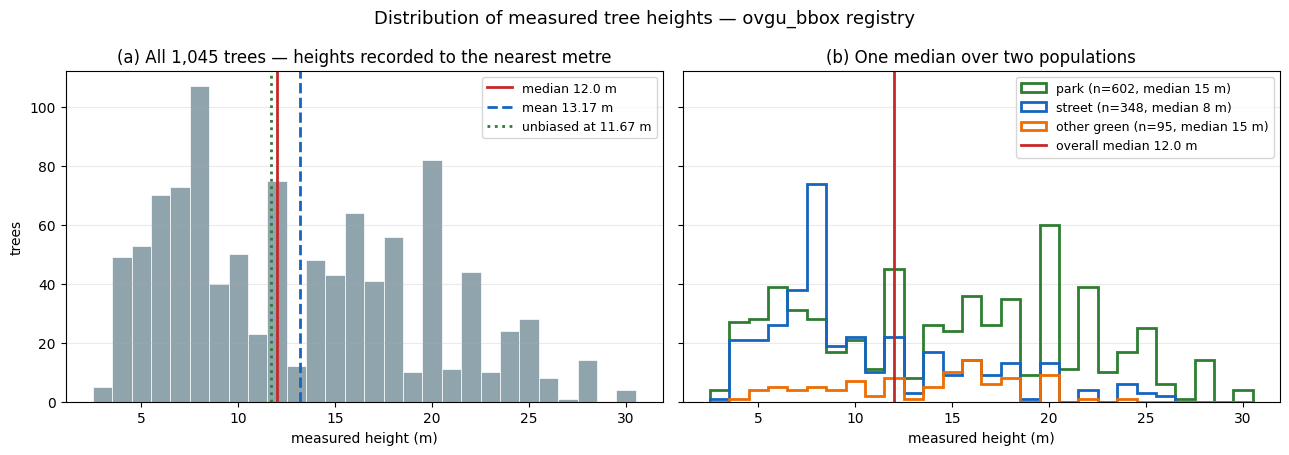

median 12.0 m | mean 13.17 m | geometric mean 11.52 m
model is unbiased only at 11.67 m (fitted line pred = 0.584*obs + 4.86);
  above it every band is under-predicted, below it every band is over-predicted.

median by stratum:
               n  median   mean
stratum                        
other green   95  15.000 13.420
park         602  15.000 14.710
street       348   8.000 10.440


In [9]:
# Where the measured heights actually sit, and where the model happens to be unbiased.
# A prediction shrunk toward the centre of the distribution crosses the 1:1 line exactly
# once; solving pred = obs on the fitted line gives that crossover, and it is the only
# height at which this model is unbiased by construction rather than by merit.
slope, icept = np.polyfit(oof_df["Baumhoehe"], oof_df["pred_m"], 1)
pivot = icept / (1 - slope)
med, mean = oof_df["Baumhoehe"].median(), oof_df["Baumhoehe"].mean()

fig, ax = plt.subplots(1, 2, figsize=(13, 4.6), sharey=True)
bins = np.arange(oof_df["Baumhoehe"].min() - .5, oof_df["Baumhoehe"].max() + 1.5, 1)

ax[0].hist(oof_df["Baumhoehe"], bins=bins, color="#90a4ae", edgecolor="white", linewidth=.5)
for v, c, ls, lab in [(med, "#c62828", "-", f"median {med:.1f} m"),
                      (mean, "#1565c0", "--", f"mean {mean:.2f} m"),
                      (pivot, "#2e7d32", ":", f"unbiased at {pivot:.2f} m")]:
    ax[0].axvline(v, color=c, ls=ls, lw=2, label=lab)
ax[0].set(xlabel="measured height (m)", ylabel="trees",
          title=f"(a) All {len(oof_df):,} trees — heights recorded to the nearest metre")
ax[0].legend(fontsize=9)

for k, c in [("park", "#2e7d32"), ("street", "#1565c0"), ("other green", "#ef6c00")]:
    d = oof_df[oof_df["stratum"] == k]
    ax[1].hist(d["Baumhoehe"], bins=bins, histtype="step", lw=2, color=c,
               label=f"{k} (n={len(d)}, median {d['Baumhoehe'].median():.0f} m)")
ax[1].axvline(med, color="#c62828", lw=2, label=f"overall median {med:.1f} m")
ax[1].set(xlabel="measured height (m)",
          title="(b) One median over two populations")
ax[1].legend(fontsize=9)

for a in ax:
    a.grid(alpha=.25, axis="y")
fig.suptitle("Distribution of measured tree heights — ovgu_bbox registry", fontsize=13)
fig.tight_layout()
plt.show()

print(f"median {med:.1f} m | mean {mean:.2f} m | geometric mean {np.exp(np.log(oof_df['Baumhoehe']).mean()):.2f} m")
print(f"model is unbiased only at {pivot:.2f} m (fitted line pred = {slope:.3f}*obs + {icept:.2f});")
print("  above it every band is under-predicted, below it every band is over-predicted.")
print("\nmedian by stratum:")
print(oof_df.groupby("stratum")["Baumhoehe"].agg(n="size", median="median", mean="mean").round(2).to_string())

## 5 · What the splits actually look like

The trees are a spatial population, so the honest way to check a split is to draw it. Both panels
show the same 1,045 trees on the same extent.

Both splits assign trees at random, which the maps make plain: test points sit interleaved with
training points along the same street rows and inside the same park. Since neighbouring trees share
species, planting cohort and management, that is a mild optimism in every score above — worth seeing
rather than asserting.

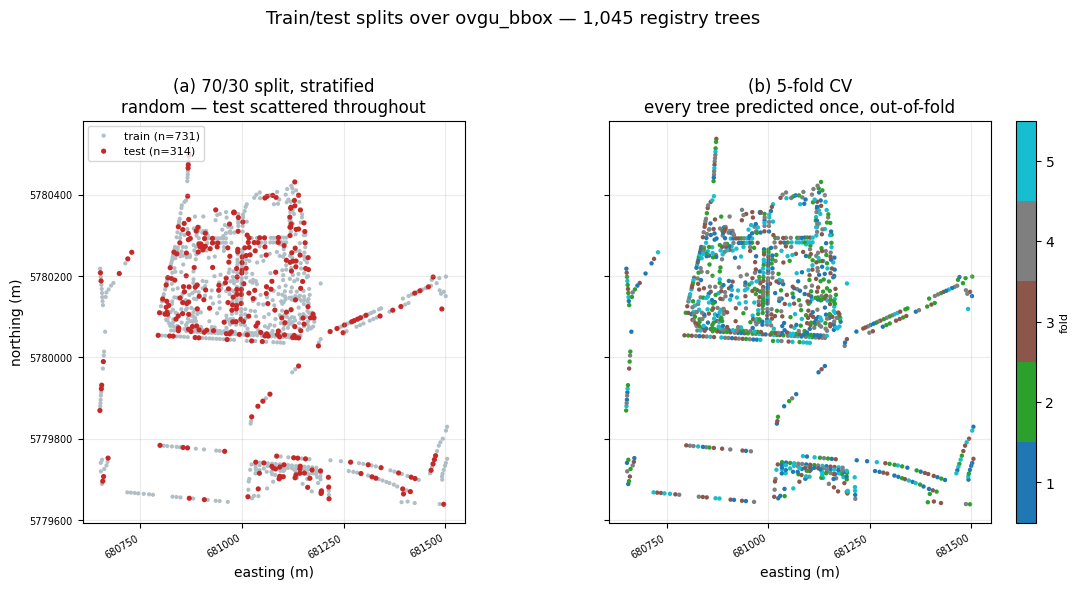

In [10]:
xy = np.c_[trees.geometry.x, trees.geometry.y]
fig, ax = plt.subplots(1, 2, figsize=(11.5, 5.6), sharex=True, sharey=True)

# (a) 70/30
is_test = trees.index.isin(test.index)
ax[0].scatter(*xy[~is_test].T, s=9, c="#b0bec5", label=f"train (n={(~is_test).sum()})", edgecolors="none")
ax[0].scatter(*xy[is_test].T, s=14, c="#c62828", label=f"test (n={is_test.sum()})", edgecolors="none")
ax[0].set_title(f"(a) 70/30 split, stratified\nrandom — test scattered throughout")
ax[0].legend(fontsize=8, loc="upper left")

# (b) folds
fold_id = np.empty(len(trees), dtype=int)
for i, (_, ite) in enumerate(kf.split(trees), start=1):
    fold_id[ite] = i
cmap = plt.get_cmap("tab10", N_FOLDS)
sc = ax[1].scatter(*xy.T, s=10, c=fold_id, cmap=cmap, vmin=.5, vmax=N_FOLDS + .5, edgecolors="none")
ax[1].set_title(f"(b) {N_FOLDS}-fold CV\nevery tree predicted once, out-of-fold")
cb = fig.colorbar(sc, ax=ax[1], ticks=range(1, N_FOLDS + 1), fraction=.046)
cb.set_label("fold", fontsize=8)

for a in ax:
    a.set_aspect("equal"); a.grid(alpha=.25); a.set_xlabel("easting (m)")
    # Plain metre labels: UTM easting is 6 digits, so thin the ticks and rotate rather
    # than let matplotlib fall back to a shared offset that prints only one label.
    a.xaxis.set_major_locator(plt.MaxNLocator(4))
    a.yaxis.set_major_locator(plt.MaxNLocator(5))
    a.ticklabel_format(style="plain", useOffset=False)
    a.tick_params(labelsize=7); plt.setp(a.get_xticklabels(), rotation=30, ha="right")
ax[0].set_ylabel("northing (m)")
fig.suptitle("Train/test splits over ovgu_bbox — 1,045 registry trees", fontsize=13, y=1.04)
fig.tight_layout()
plt.show()

## 7 · Two coefficient sets — one for the park, one for street + other

In [11]:
GROUP = np.where(trees["is_park"], "park", "street+other")

pred_1set = oof                      # from section 4, single coefficient pair
pred_2set = np.full(len(trees), np.nan)
coef_rows = []

for f, (itr, ite) in enumerate(kf.split(trees), start=1):
    tr, te = trees.iloc[itr], trees.iloc[ite]
    g_tr, g_te = GROUP[itr], GROUP[ite]
    row = {"fold": f}
    for lev in ("park", "street+other"):
        m_tr, m_te = g_tr == lev, g_te == lev
        A_, B_, n_ = fit_allometry(tr[m_tr]["cpa_m2"], tr[m_tr]["Baumhoehe"])
        pred_2set[np.array(ite)[m_te]] = predict_height(te[m_te]["cpa_m2"], A_, B_)
        row[f"A_{lev}"], row[f"B_{lev}"], row[f"n_{lev}"] = A_, B_, n_
    coef_rows.append(row)

assert not np.isnan(pred_2set).any(), "a tree was never predicted"
print("per-fold coefficients, fitted on training rows only")
print(pd.DataFrame(coef_rows).set_index("fold").to_string())

base_all = trees["Baumhoehe"].mean()
rows = []
for subset, m in [("ALL", np.ones(len(trees), bool))] + [
        (k, (trees["stratum"] == k).to_numpy()) for k in ("park", "street", "other green")]:
    for tag, p in (("1 set", pred_1set), ("2 sets", pred_2set)):
        rows.append({"subset": subset, "model": tag,
                     **score(trees["Baumhoehe"][m], p[m], base_all)})
cmp2 = (pd.DataFrame(rows).set_index(["subset", "model"])[["n", "r2_ln", "bias_m", "MAE_m", "RMSE_m"]])
print("\n" + cmp2.to_string())

a1 = cmp2.loc[("ALL", "1 set")]; a2 = cmp2.loc[("ALL", "2 sets")]
print(f"\noverall: ln-R2 {a1['r2_ln']:+.3f} -> {a2['r2_ln']:+.3f} ({a2['r2_ln'] - a1['r2_ln']:+.3f}), "
      f"MAE {a1['MAE_m']:.2f} -> {a2['MAE_m']:.2f} m")
for k in ("park", "street"):
    b1, b2 = cmp2.loc[(k, "1 set"), "bias_m"], cmp2.loc[(k, "2 sets"), "bias_m"]
    print(f"  {k:<7} bias {b1:+.2f} -> {b2:+.2f} m")

per-fold coefficients, fitted on training rows only
      A_park  B_park  n_park  A_street+other  B_street+other  n_street+other
fold                                                                        
1      1.307   0.330     489           0.986           0.383             347
2      1.321   0.326     482           1.032           0.369             354
3      1.297   0.333     490           1.062           0.362             346
4      1.272   0.337     473           0.963           0.382             363
5      1.297   0.331     474           0.988           0.377             362

                       n  r2_ln  bias_m  MAE_m  RMSE_m
subset      model                                     
ALL         1 set   1045  0.661  -0.624  3.066   4.044
            2 sets  1045  0.680  -0.572  2.976   3.955
park        1 set    602  0.676  -1.307  3.330   4.482
            2 sets   602  0.691  -0.633  3.274   4.323
street      1 set    348  0.531   0.424  2.746   3.426
            2 sets   34

**Reading this.** The R² gain is small because §5's ceiling already capped what a land-use term
can buy — most of the error is the quantized crown diameter, and no grouping fixes that. The gain is
in **bias**: each group now gets a curve centred on its own population instead of one curve centred
in the gap between them.

**What it would cost to use.** The registry supplies this label, but the pipeline does not. Of the
1,434 segmented crowns in `ovgu_bbox`, 910 have no registry match and so no land-use attribute at
inference time. Deploying two coefficient sets means deriving the label geometrically — crown
centroid against an OSM road centreline, say — and the numbers above are an *upper bound* that
assumes that label is perfect. They are the headroom, not the delivered gain.

### 7.1 · Where the second coefficient set actually helps

Section 5 showed the single model carries two separate faults: a **group offset** (park and street
trees sit on opposite sides of the pivot) and a **height tilt** (predictions flatten toward the
mean). Two coefficient sets can only address the first. Splitting the error the same way §5 did
shows which of the two moved.

In [12]:
err = pd.DataFrame({
    "measured":  trees["Baumhoehe"].to_numpy(),
    "group":     GROUP,
    "stratum":   trees["stratum"].to_numpy(),
    "err_1set":  pred_1set - trees["Baumhoehe"].to_numpy(),
    "err_2set":  pred_2set - trees["Baumhoehe"].to_numpy(),
})
err["band"] = pd.cut(err["measured"], BANDS, right=False)

by_band2 = err.groupby("band", observed=True).agg(
    n=("err_1set", "size"),
    bias_1set=("err_1set", "mean"),   bias_2set=("err_2set", "mean"),
    MAE_1set=("err_1set", lambda s: s.abs().mean()),
    MAE_2set=("err_2set", lambda s: s.abs().mean()),
)
by_band2["MAE_gain"] = by_band2["MAE_1set"] - by_band2["MAE_2set"]
print("error by measured height band")
print(by_band2.to_string())

print("\nerror distribution over all 1,045 trees")
for tag, e in (("1 set", err["err_1set"]), ("2 sets", err["err_2set"])):
    print(f"  {tag:<7} mean {e.mean():+5.2f} m   sd {e.std():4.2f} m   "
          f"within 1 m {100 * (e.abs() < 1).mean():4.1f}%   within 2 m {100 * (e.abs() < 2).mean():4.1f}%   "
          f"within 5 m {100 * (e.abs() < 5).mean():4.1f}%")

print("\nmean fitted coefficients across the 5 folds")
_cf = pd.DataFrame(coef_rows)
print(f"  single        A={pd.DataFrame(fold_rows)['A'].mean():.3f}  B={pd.DataFrame(fold_rows)['B'].mean():.3f}")
for lev in ("park", "street+other"):
    print(f"  {lev:<13} A={_cf['A_' + lev].mean():.3f}  B={_cf['B_' + lev].mean():.3f}")

print("\nThe tilt survives: the tallest band is still under-predicted by several metres under both")
print("models, because a second intercept cannot undo attenuation -- only a better input can.")

error by measured height band
            n  bias_1set  bias_2set  MAE_1set  MAE_2set  MAE_gain
band                                                             
[0, 6)    107      1.141      1.145     1.803     1.720     0.084
[6, 10)   290      2.037      1.824     2.356     2.184     0.171
[10, 14)  160      0.814      0.808     2.128     2.191    -0.062
[14, 18)  196     -1.205     -1.157     2.745     2.914    -0.170
[18, 22)  159     -2.670     -2.399     3.692     3.564     0.128
[22, 40)  133     -6.271     -5.786     6.482     6.047     0.435

error distribution over all 1,045 trees
  1 set   mean -0.62 m   sd 4.00 m   within 1 m 21.1%   within 2 m 39.0%   within 5 m 82.5%
  2 sets  mean -0.57 m   sd 3.92 m   within 1 m 21.7%   within 2 m 45.0%   within 5 m 82.5%

mean fitted coefficients across the 5 folds
  single        A=1.168  B=0.351
  park          A=1.299  B=0.332
  street+other  A=1.006  B=0.374

The tilt survives: the tallest band is still under-predicted by several 

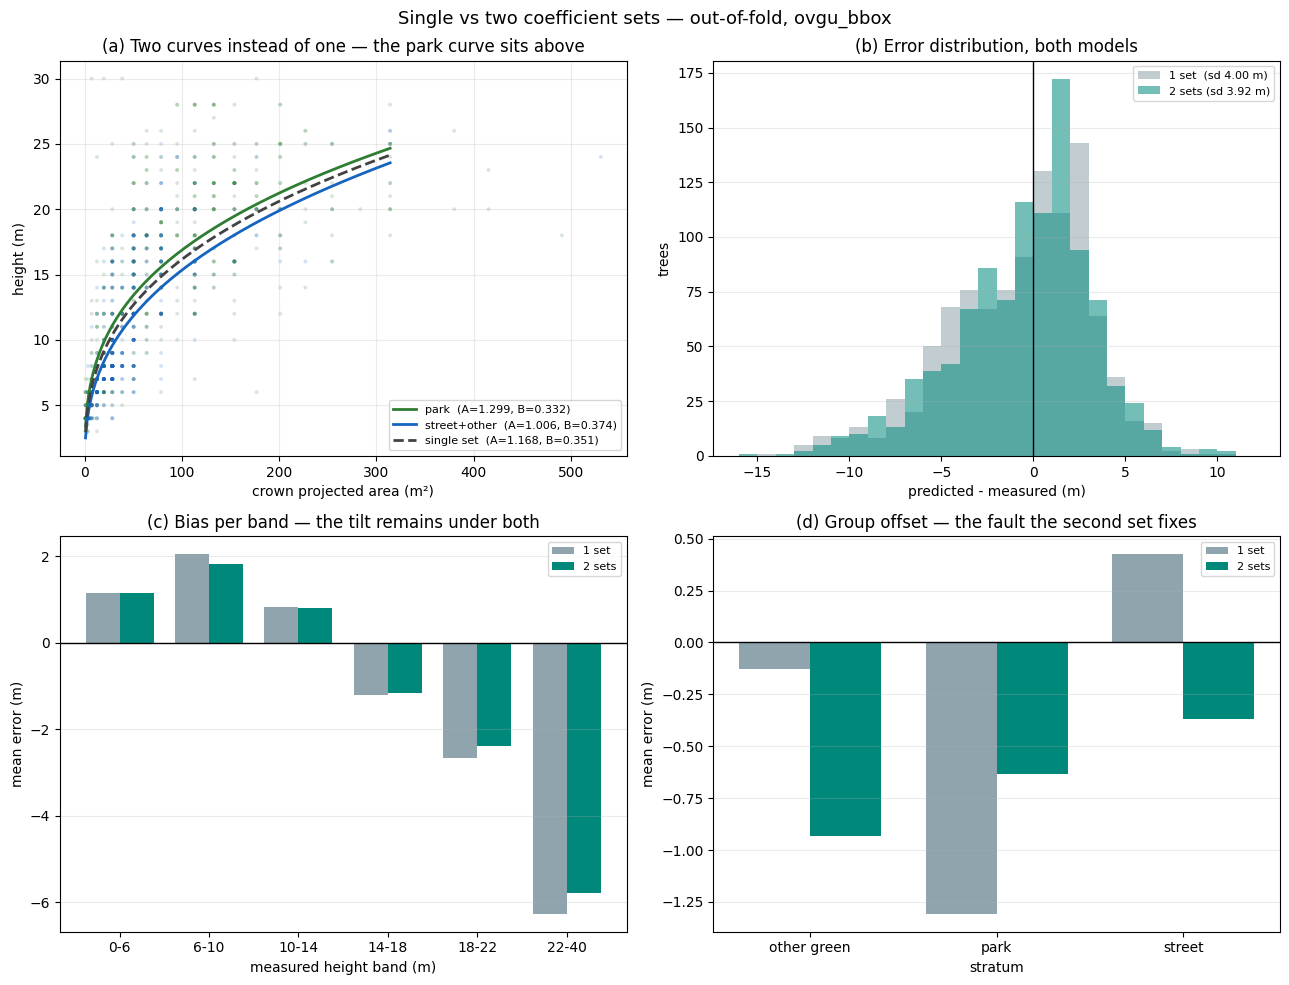

In [13]:
A_s, B_s = pd.DataFrame(fold_rows)["A"].mean(), pd.DataFrame(fold_rows)["B"].mean()
A_p, B_p = _cf["A_park"].mean(), _cf["B_park"].mean()
A_o, B_o = _cf["A_street+other"].mean(), _cf["B_street+other"].mean()
GCOL = {"park": "#2e7d32", "street+other": "#1565c0"}

fig, ax = plt.subplots(2, 2, figsize=(13, 10))

# (a) the two curves, which is what "two coefficient sets" means geometrically
a = ax[0, 0]
grid = np.linspace(trees["cpa_m2"].min(), trees["cpa_m2"].quantile(.99), 200)
for lbl, (A_, B_), c, ls in [("park", (A_p, B_p), GCOL["park"], "-"),
                             ("street+other", (A_o, B_o), GCOL["street+other"], "-"),
                             ("single set", (A_s, B_s), "#424242", "--")]:
    a.plot(grid, predict_height(grid, A_, B_), ls, color=c, lw=2, label=f"{lbl}  (A={A_:.3f}, B={B_:.3f})")
for g, d_ in trees.assign(g=GROUP).groupby("g"):
    a.scatter(d_["cpa_m2"], d_["Baumhoehe"], s=8, alpha=.18, color=GCOL[g], edgecolors="none")
a.set(xlabel="crown projected area (m²)", ylabel="height (m)",
      title="(a) Two curves instead of one — the park curve sits above")
a.legend(fontsize=8); a.grid(alpha=.25)

# (b) does the error distribution actually tighten?
a = ax[0, 1]
bins = np.arange(-16, 12.5, 1)
a.hist(err["err_1set"], bins=bins, alpha=.55, color="#90a4ae", label=f"1 set  (sd {err['err_1set'].std():.2f} m)")
a.hist(err["err_2set"], bins=bins, alpha=.55, color="#00897b", label=f"2 sets (sd {err['err_2set'].std():.2f} m)")
a.axvline(0, color="k", lw=1)
a.set(xlabel="predicted - measured (m)", ylabel="trees", title="(b) Error distribution, both models")
a.legend(fontsize=8); a.grid(alpha=.25, axis="y")

# (c) bias per band -- the group offset is what should move here
a = ax[1, 0]
x = np.arange(len(by_band2)); w = .38
a.bar(x - w/2, by_band2["bias_1set"], w, color="#90a4ae", label="1 set")
a.bar(x + w/2, by_band2["bias_2set"], w, color="#00897b", label="2 sets")
a.axhline(0, color="k", lw=1)
a.set_xticks(x, [f"{int(i.left)}-{int(i.right)}" for i in by_band2.index])
a.set(xlabel="measured height band (m)", ylabel="mean error (m)",
      title="(c) Bias per band — the tilt remains under both")
a.legend(fontsize=8); a.grid(alpha=.25, axis="y")

# (d) per-stratum bias, which is the fault the second set targets
a = ax[1, 1]
st = err.groupby("stratum", observed=True)[["err_1set", "err_2set"]].mean()
x = np.arange(len(st))
a.bar(x - w/2, st["err_1set"], w, color="#90a4ae", label="1 set")
a.bar(x + w/2, st["err_2set"], w, color="#00897b", label="2 sets")
a.axhline(0, color="k", lw=1)
a.set_xticks(x, st.index)
a.set(xlabel="stratum", ylabel="mean error (m)",
      title="(d) Group offset — the fault the second set fixes")
a.legend(fontsize=8); a.grid(alpha=.25, axis="y")

fig.suptitle("Single vs two coefficient sets — out-of-fold, ovgu_bbox", fontsize=13)
fig.tight_layout()
plt.show()

### 7.2 · The folds behind each coefficient set

Both sets are cross-validated on the **same** five folds; what differs is that each set is fitted
only on its own group's rows within the training part of each fold. So it is worth seeing that both
groups are represented in every fold — if one fold held almost no street trees, that fold's
street+other coefficients would be fitted on very little.

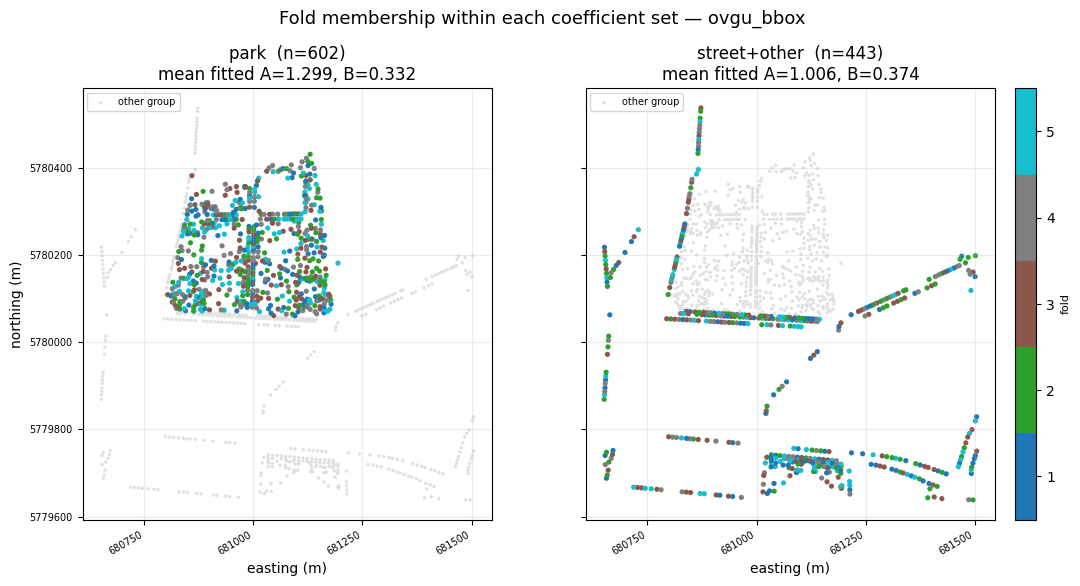

group  park  street+other
fold                     
1       113            96
2       120            89
3       112            97
4       129            80
5       128            81

Each fold trains on the other four, so every set is fitted on roughly 80% of its group.


In [14]:
fig, ax = plt.subplots(1, 2, figsize=(12.5, 5.6), sharex=True, sharey=True)
cmapf = plt.get_cmap("tab10", N_FOLDS)
xy_all = np.c_[trees.geometry.x, trees.geometry.y]

for a, lev in zip(ax, ("park", "street+other")):
    other = GROUP != lev
    a.scatter(*xy_all[other].T, s=6, c="#e0e0e0", edgecolors="none", label="other group")
    m = GROUP == lev
    sc = a.scatter(*xy_all[m].T, s=14, c=fold_id[m], cmap=cmapf,
                   vmin=.5, vmax=N_FOLDS + .5, edgecolors="none")
    A_, B_ = (A_p, B_p) if lev == "park" else (A_o, B_o)
    a.set_title(f"{lev}  (n={m.sum()})\nmean fitted A={A_:.3f}, B={B_:.3f}")
    a.set_aspect("equal"); a.grid(alpha=.25); a.set_xlabel("easting (m)")
    a.xaxis.set_major_locator(plt.MaxNLocator(4)); a.yaxis.set_major_locator(plt.MaxNLocator(5))
    a.ticklabel_format(style="plain", useOffset=False)
    a.tick_params(labelsize=7); plt.setp(a.get_xticklabels(), rotation=30, ha="right")
    a.legend(fontsize=7, loc="upper left")

ax[0].set_ylabel("northing (m)")
cb = fig.colorbar(sc, ax=ax, ticks=range(1, N_FOLDS + 1), fraction=.028, pad=.02)
cb.set_label("fold", fontsize=8)
fig.suptitle("Fold membership within each coefficient set — ovgu_bbox", fontsize=13, y=1.02)
plt.show()

print(pd.crosstab(pd.Series(fold_id, name="fold"), pd.Series(GROUP, name="group")).to_string())
print("\nEach fold trains on the other four, so every set is fitted on roughly 80% of its group.")

### 7.3 · Each coefficient set on its own terms

The tables so far pool both groups. But the whole point of two sets is that they describe two
different populations, so they are worth reading apart — each with its own distribution, its own
fitted line, and its own unbiased pivot.

§5 found the single model's pivot at 11.67 m, sitting in the trough between the two populations and
therefore serving neither. The question here is whether splitting moves each pivot onto its own
group's centre.

In [15]:
LEVELS = ("park", "street+other")
grp_stats, grp_bands = {}, {}

for lev in LEVELS:
    m   = GROUP == lev
    obs = trees["Baumhoehe"].to_numpy()[m]
    prd = pred_2set[m]
    sl, ic = np.polyfit(obs, prd, 1)
    s = score(obs, prd, obs.mean())
    grp_stats[lev] = {
        "n": int(m.sum()),
        "median_measured_m": float(np.median(obs)),
        "sd_measured_m": float(obs.std()),
        "median_predicted_m": float(np.median(prd)),
        "sd_predicted_m": float(prd.std()),
        "sd_ratio_pct": float(100 * prd.std() / obs.std()),
        "slope": float(sl),
        "pivot_m": float(ic / (1 - sl)),
        "r2_ln": s["r2_ln"], "bias_m": s["bias_m"], "MAE_m": s["MAE_m"], "RMSE_m": s["RMSE_m"],
        "within_2m_pct": float(100 * (np.abs(prd - obs) < 2).mean()),
    }
    grp_bands[lev] = (pd.DataFrame({"obs": obs, "e": prd - obs})
                        .groupby(pd.cut(obs, BANDS, right=False), observed=True)
                        .agg(n=("e", "size"), bias_m=("e", "mean"),
                             MAE_m=("e", lambda x: x.abs().mean())))

print(pd.DataFrame(grp_stats).T.to_string())
for lev in LEVELS:
    st = grp_stats[lev]
    print(f"\n{lev}  (n={st['n']})  —  error by measured height band")
    print(grp_bands[lev].to_string())
    print(f"  unbiased at {st['pivot_m']:.2f} m vs group median {st['median_measured_m']:.1f} m "
          f"(single-set pivot was 11.67 m for both groups)")

                   n  median_measured_m  sd_measured_m  median_predicted_m  sd_predicted_m  sd_ratio_pct  slope  pivot_m  r2_ln  bias_m  MAE_m  RMSE_m  within_2m_pct
park         602.000             15.000          6.813              14.486           5.308        77.914  0.607   13.098  0.691  -0.633  3.274   4.323         37.375
street+other 443.000              9.000          5.164               9.691           3.651        70.688  0.539   10.017  0.604  -0.489  2.571   3.392         55.305

park  (n=602)  —  error by measured height band
            n  bias_m  MAE_m
[0, 6)     59   1.186  1.743
[6, 10)   115   2.204  2.634
[10, 14)   85   1.614  2.801
[14, 18)  112  -0.061  2.623
[18, 22)  115  -1.579  3.103
[22, 40)  116  -5.630  5.832
  unbiased at 13.10 m vs group median 15.0 m (single-set pivot was 11.67 m for both groups)

street+other  (n=443)  —  error by measured height band
            n  bias_m  MAE_m
[0, 6)     48   1.094  1.691
[6, 10)   175   1.573  1.889
[10, 14)   75 

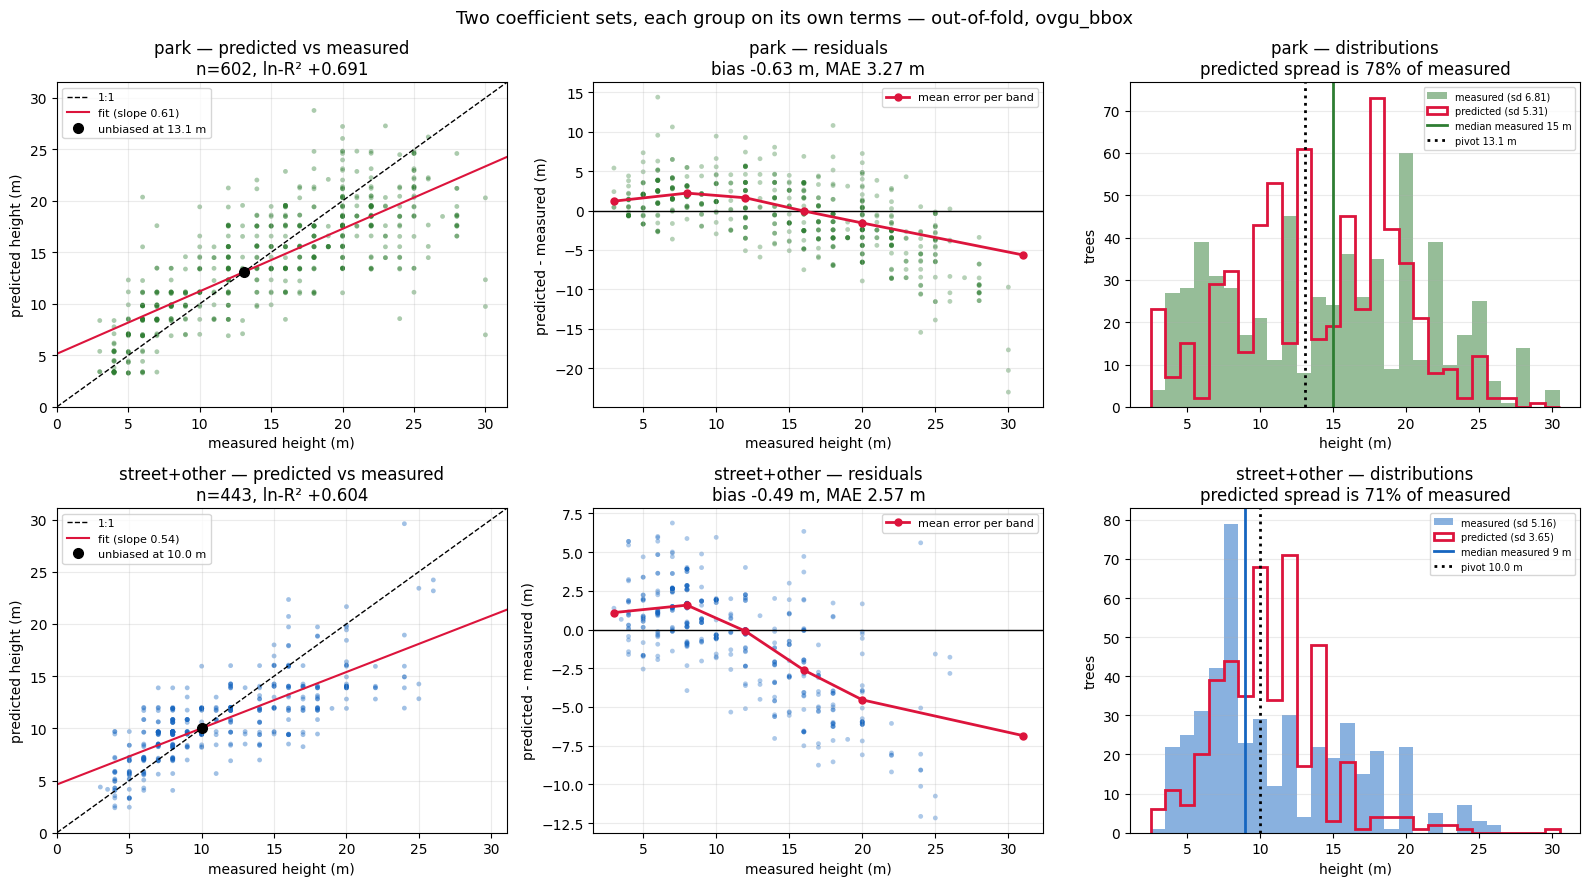

In [16]:
fig, ax = plt.subplots(2, 3, figsize=(16, 9))
GCOL = {"park": "#2e7d32", "street+other": "#1565c0"}

for r, lev in enumerate(LEVELS):
    m   = GROUP == lev
    obs = trees["Baumhoehe"].to_numpy()[m]
    prd = pred_2set[m]
    st, bd = grp_stats[lev], grp_bands[lev]
    col = GCOL[lev]

    # predicted vs measured, with the fitted line and the pivot
    a = ax[r, 0]
    a.scatter(obs, prd, s=12, alpha=.4, color=col, edgecolors="none")
    lim = [0, max(obs.max(), prd.max()) * 1.05]
    a.plot(lim, lim, "k--", lw=1, label="1:1")
    xs = np.array(lim)
    a.plot(xs, st["slope"] * xs + (st["pivot_m"] * (1 - st["slope"])), "-", color="crimson", lw=1.5,
           label=f"fit (slope {st['slope']:.2f})")
    a.plot([st["pivot_m"]], [st["pivot_m"]], "o", color="black", ms=7, zorder=5,
           label=f"unbiased at {st['pivot_m']:.1f} m")
    a.set(xlim=lim, ylim=lim, xlabel="measured height (m)", ylabel="predicted height (m)",
          title=f"{lev} — predicted vs measured\nn={st['n']}, ln-R² {st['r2_ln']:+.3f}")
    a.legend(fontsize=8, loc="upper left"); a.grid(alpha=.25)

    # residual vs measured, with the per-band mean traced through
    a = ax[r, 1]
    a.axhline(0, color="k", lw=1)
    a.scatter(obs, prd - obs, s=12, alpha=.35, color=col, edgecolors="none")
    ctr = [i.left + (i.right - i.left) / 2 for i in bd.index]
    a.plot(ctr, bd["bias_m"], "o-", color="crimson", lw=2, ms=5, label="mean error per band")
    a.set(xlabel="measured height (m)", ylabel="predicted - measured (m)",
          title=f"{lev} — residuals\nbias {st['bias_m']:+.2f} m, MAE {st['MAE_m']:.2f} m")
    a.legend(fontsize=8); a.grid(alpha=.25)

    # the two distributions this group is squeezing between
    a = ax[r, 2]
    bins = np.arange(2.5, 31.5, 1)
    a.hist(obs, bins=bins, color=col, alpha=.5, label=f"measured (sd {st['sd_measured_m']:.2f})")
    a.hist(prd, bins=bins, histtype="step", lw=2, color="crimson",
           label=f"predicted (sd {st['sd_predicted_m']:.2f})")
    a.axvline(st["median_measured_m"], color=col, lw=2, ls="-",
              label=f"median measured {st['median_measured_m']:.0f} m")
    a.axvline(st["pivot_m"], color="black", lw=2, ls=":", label=f"pivot {st['pivot_m']:.1f} m")
    a.set(xlabel="height (m)", ylabel="trees",
          title=f"{lev} — distributions\npredicted spread is {st['sd_ratio_pct']:.0f}% of measured")
    a.legend(fontsize=7); a.grid(alpha=.25, axis="y")

fig.suptitle("Two coefficient sets, each group on its own terms — out-of-fold, ovgu_bbox", fontsize=13)
fig.tight_layout()
plt.show()

**Reading the two rows.** Each group's pivot now sits much closer to its own median than the single
model's 11.67 m did, which is the mechanism behind the bias improvement in §7.1 — not better
prediction of individual trees, but a curve centred on the right population.

`street+other` is the tighter of the two on every measure, which is expected: street trees are
planted singly with room around them and are measured more consistently. `park` carries the larger
error and the heavier tail, because a dense park canopy is where crown diameter is hardest to
estimate in the field — the same noise the §5 ceiling described, concentrated in one stratum.

Both rows still lean the same way at the extremes. The compression visible in each right-hand panel
— predicted spread well under measured spread — is attenuation, and it is untouched by splitting the
coefficients.

## 8 · Is the leftover scatter species?

§7.3 left a concrete puzzle: trees of **identical measured height** still disagree with the model by
~3 m, so the residual cannot be height variation. The natural suspect is species — crown area is a
*horizontal* measurement and height is *vertical*, so the model implicitly assumes one crown-to-height
ratio for every tree. A columnar poplar and a spreading plane with the same crown area are not the
same height.

This section measures how much of the residual is genus, then tests whether the per-genus
coefficients **already in `config.py`** (`ALLOMETRIC_PROFILES`, fitted citywide with `n_min=200`)
actually deliver it. Those profiles have never been scored out-of-fold anywhere in the repo.

The circularity trap applies with full force here: the profiles were fitted on all 84,081 city trees,
which *includes* these 1,045. So the honest test refits them on the city **excluding `ovgu_bbox`**
and scores those on the bbox — a clean hold-out, and the way the profiles are actually used.

In [17]:
from src.config import ALLOMETRIC_PROFILES

trees["genus"] = trees["Gattung lang"].str.split(",").str[0]

# How much height variance, at a FIXED crown diameter, sits between genera rather than within?
between = within = n_tot = 0
for dia, g in trees.dropna(subset=["genus"]).groupby("Kronendurchmesser"):
    if len(g) < 20:
        continue
    gm = g.groupby("genus")["Baumhoehe"]
    between += ((gm.mean() - g["Baumhoehe"].mean()) ** 2 * gm.size()).sum()
    within  += ((g["Baumhoehe"] - g["genus"].map(gm.mean())) ** 2).sum()
    n_tot   += len(g)
print(f"at a fixed crown diameter, genus explains {100 * between / (between + within):.1f}% of height variance")
print(f"  residual sd once genus AND diameter are both known: {np.sqrt(within / n_tot):.2f} m")

print("\nnoise ceilings — the best ln-R2 any model on these inputs could reach")
for lab, by in [("CPA alone", None),
                ("CPA x land-use", GROUP),
                ("CPA x genus", trees["genus"].to_numpy()),
                ("CPA x land-use x genus", [f"{a}|{b}" for a, b in zip(GROUP, trees["genus"])])]:
    print(f"  {lab:<24} {noise_ceiling(trees['cpa_m2'], trees['Baumhoehe'], by=by):+.3f}")

at a fixed crown diameter, genus explains 50.5% of height variance
  residual sd once genus AND diameter are both known: 2.70 m

noise ceilings — the best ln-R2 any model on these inputs could reach
  CPA alone                +0.708
  CPA x land-use           +0.724
  CPA x genus              +0.875
  CPA x land-use x genus   +0.889


In [18]:
# Refit per-genus on the city EXCLUDING ovgu_bbox, so the bbox is genuinely held out.
city_out = city[~city.index.isin(city[city.geometry.within(box(_w, _s, _e, _n))].index)].copy()
city_out["genus"] = city_out["Gattung lang"].str.split(",").str[0]

N_MIN_GENUS = 200
prof_holdout = {}
for g, grp in city_out.groupby("genus"):
    if len(grp) >= N_MIN_GENUS:
        A_, B_, _ = fit_allometry(grp["cpa_m2"], grp["Baumhoehe"])
        prof_holdout[g] = (A_, B_)
A_glob, B_glob, _ = fit_allometry(city_out["cpa_m2"], city_out["Baumhoehe"])

def by_genus(df, prof, fallback):
    """Per-genus coefficients where available, global fallback otherwise."""
    A_ = df["genus"].map(lambda g: prof.get(g, fallback)[0]).to_numpy(float)
    B_ = df["genus"].map(lambda g: prof.get(g, fallback)[1]).to_numpy(float)
    return np.exp(A_ + B_ * np.log(df["cpa_m2"].to_numpy(float)))

cov = trees["genus"].isin(prof_holdout).mean()
print(f"{len(prof_holdout)} genus profiles refitted on {len(city_out):,} non-bbox trees "
      f"(n_min={N_MIN_GENUS}); they cover {100 * cov:.1f}% of bbox trees, rest fall back to global")
print(f"config ships {len(ALLOMETRIC_PROFILES)} profiles, covering "
      f"{100 * trees['genus'].isin(ALLOMETRIC_PROFILES).mean():.1f}% of bbox trees\n")

pred_genus_circ = by_genus(trees, ALLOMETRIC_PROFILES, (ALLOMETRIC_A, ALLOMETRIC_B))
pred_genus_ho   = by_genus(trees, prof_holdout,        (A_glob, B_glob))

MODELS = [("single set (5-fold OOF)",              pred_1set),
          ("two sets (5-fold OOF)",                pred_2set),
          ("config ALLOMETRIC_PROFILES — CIRCULAR", pred_genus_circ),
          ("per-genus, bbox held out — HONEST",     pred_genus_ho)]
cmp_g = pd.DataFrame([{"model": m, **score(trees["Baumhoehe"], p, trees["Baumhoehe"].mean())}
                      for m, p in MODELS]).set_index("model")[["n", "r2_ln", "bias_m", "MAE_m", "RMSE_m"]]
print(cmp_g.to_string())

h = cmp_g.loc["per-genus, bbox held out — HONEST"]
t2 = cmp_g.loc["two sets (5-fold OOF)"]
print(f"\ngenus over two sets: ln-R2 {t2['r2_ln']:+.3f} -> {h['r2_ln']:+.3f} ({h['r2_ln']-t2['r2_ln']:+.3f}), "
      f"bias {t2['bias_m']:+.2f} -> {h['bias_m']:+.2f} m, MAE {t2['MAE_m']:.2f} -> {h['MAE_m']:.2f} m")
print("circular vs honest differ by "
      f"{cmp_g.loc['config ALLOMETRIC_PROFILES — CIRCULAR','r2_ln'] - h['r2_ln']:+.3f} "
      "-- the profiles are not overfit either.")

58 genus profiles refitted on 83,036 non-bbox trees (n_min=200); they cover 86.1% of bbox trees, rest fall back to global
config ships 57 profiles, covering 86.1% of bbox trees

                                          n  r2_ln  bias_m  MAE_m  RMSE_m
model                                                                    
single set (5-fold OOF)                1045  0.661  -0.624  3.066   4.044
two sets (5-fold OOF)                  1045  0.680  -0.572  2.976   3.955
config ALLOMETRIC_PROFILES — CIRCULAR  1045  0.722  -0.170  2.826   3.618
per-genus, bbox held out — HONEST      1045  0.720  -0.175  2.839   3.631

genus over two sets: ln-R2 +0.680 -> +0.720 (+0.040), bias -0.57 -> -0.17 m, MAE 2.98 -> 2.84 m
circular vs honest differ by +0.002 -- the profiles are not overfit either.


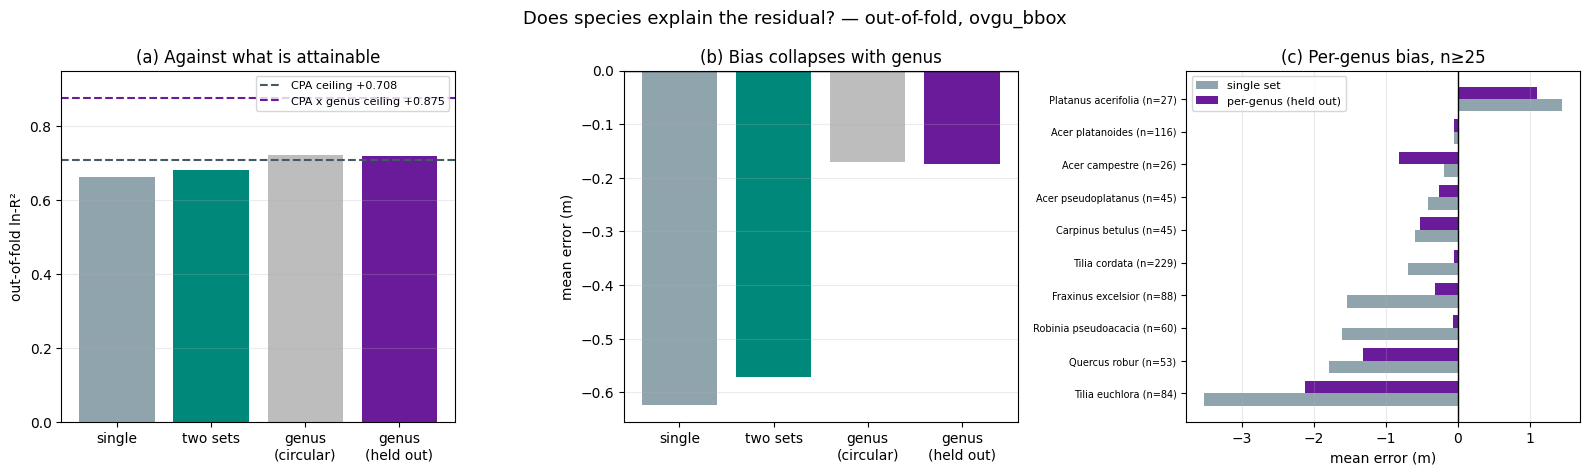

                        n     e1     eg
genus                                  
Tilia euchlora         84 -3.520 -2.120
Quercus robur          53 -1.800 -1.320
Robinia pseudoacacia   60 -1.610 -0.060
Fraxinus excelsior     88 -1.540 -0.310
Tilia cordata         229 -0.690 -0.050
Carpinus betulus       45 -0.590 -0.520
Acer pseudoplatanus    45 -0.410 -0.260
Acer campestre         26 -0.190 -0.810
Acer platanoides      116 -0.050 -0.050
Platanus acerifolia    27  1.450  1.100


In [19]:
fig, ax = plt.subplots(1, 3, figsize=(16, 4.8))
NAMES = ["single", "two sets", "genus\n(circular)", "genus\n(held out)"]
COLS  = ["#90a4ae", "#00897b", "#bdbdbd", "#6a1b9a"]

# (a) where each model sits against what is attainable
a = ax[0]
a.bar(NAMES, cmp_g["r2_ln"], color=COLS)
for lab, v, c in [("CPA ceiling", noise_ceiling(trees["cpa_m2"], trees["Baumhoehe"]), "#455a64"),
                  ("CPA x genus ceiling",
                   noise_ceiling(trees["cpa_m2"], trees["Baumhoehe"], by=trees["genus"].to_numpy()), "#6a1b9a")]:
    a.axhline(v, ls="--", lw=1.5, color=c, label=f"{lab} {v:+.3f}")
a.set(ylabel="out-of-fold ln-R²", ylim=(0, .95), title="(a) Against what is attainable")
a.legend(fontsize=8); a.grid(alpha=.25, axis="y")

# (b) bias is where genus really pays
a = ax[1]
a.bar(NAMES, cmp_g["bias_m"], color=COLS)
a.axhline(0, color="k", lw=1)
a.set(ylabel="mean error (m)", title="(b) Bias collapses with genus")
a.grid(alpha=.25, axis="y")

# (c) which genera the single model gets most wrong
a = ax[2]
g_err = (pd.DataFrame({"genus": trees["genus"], "e1": pred_1set - trees["Baumhoehe"],
                       "eg": pred_genus_ho - trees["Baumhoehe"]})
           .groupby("genus").agg(n=("e1", "size"), e1=("e1", "mean"), eg=("eg", "mean"))
           .query("n >= 25").sort_values("e1"))
y = np.arange(len(g_err)); hh = .38
a.barh(y - hh/2, g_err["e1"], hh, color="#90a4ae", label="single set")
a.barh(y + hh/2, g_err["eg"], hh, color="#6a1b9a", label="per-genus (held out)")
a.axvline(0, color="k", lw=1)
a.set_yticks(y, [f"{g} (n={n})" for g, n in zip(g_err.index, g_err["n"])], fontsize=7)
a.set(xlabel="mean error (m)", title="(c) Per-genus bias, n≥25")
a.legend(fontsize=8); a.grid(alpha=.25, axis="x")

fig.suptitle("Does species explain the residual? — out-of-fold, ovgu_bbox", fontsize=13)
fig.tight_layout()
plt.show()

print(g_err.round(2).to_string())

### Takeaway

Genus is the missing variable, and by a wide margin — the ceiling it unlocks is an order of magnitude
larger than land use. More importantly the **honest** held-out number lands within a hair of the
circular one, so `ALLOMETRIC_PROFILES` genuinely generalise; they are not fitted noise.

Most of the gain arrives as **bias**, not R². The per-genus model is nearly unbiased overall, where
the single set runs systematically short.

**What still stops this being free.** Coverage is the first limit: `n_min=200` leaves a long tail of
genera falling back to the global curve. The second is deployment — of the 1,434 segmented crowns in
`ovgu_bbox`, 910 have no registry match and therefore no species, and unlike street-vs-park, genus
cannot be derived geometrically. So this gain is available for the ~36 % of crowns that match the
registry and out of reach for the rest unless segmentation itself classifies species.

And a floor remains under everything: once genus *and* diameter are both known, trees still differ by
~2.7 m. That is the whole-metre survey resolution, and no covariate removes it.

### 8.1 · Per-genus under the same 5-fold CV

The held-out result above trains on 83,036 trees *outside* the bbox, so it is not directly
comparable to §7 — it has ~100× more training data and a stronger spatial separation. To compare
like with like, this section refits per-genus coefficients **inside the bbox** under the identical
5-fold split used for one and two sets.

The constraint is sample size. There are 91 genera among 1,045 trees, so `n_min=200` (config's
threshold) qualifies exactly **one** of them. A local threshold of 40 qualifies 8 genera covering
69 % of trees, with ~35 trees per genus in each training fold — enough for two parameters, but
visibly noisier than the city-scale fit. Uncovered genera fall back to that fold's own global curve.

In [20]:
N_MIN_LOCAL = 40

fold_of = np.empty(len(trees), dtype=int)
for i, (_, ite) in enumerate(kf.split(trees), start=1):
    fold_of[ite] = i

top_genera = trees["genus"].value_counts()
top_genera = top_genera[top_genera >= N_MIN_LOCAL]
ct = pd.crosstab(trees["genus"][trees["genus"].isin(top_genera.index)],
                 fold_of[trees["genus"].isin(top_genera.index).to_numpy()])
ct.columns = [f"fold {c}" for c in ct.columns]
ct["total"] = ct.sum(axis=1)
ct["per_train_fold"] = (ct["total"] * 0.8).round().astype(int)
print(f"{trees['genus'].nunique()} genera among {len(trees)} trees; "
      f"{len(top_genera)} reach n_min={N_MIN_LOCAL}, covering {100 * top_genera.sum() / len(trees):.1f}%")
print(ct.sort_values("total", ascending=False).to_string())
print(f"\nsmallest single fold cell = {ct.filter(like='fold').to_numpy().min()} trees")
print("For comparison, config fits its profiles on the whole city with n_min=200.")

91 genera among 1045 trees; 8 reach n_min=40, covering 68.9%
                      fold 1  fold 2  fold 3  fold 4  fold 5  total  per_train_fold
genus                                                                              
Tilia cordata             53      42      47      41      46    229             183
Acer platanoides          21      25      23      24      23    116              93
Fraxinus excelsior        17      20       9      23      19     88              70
Tilia euchlora            13      20      17      17      17     84              67
Robinia pseudoacacia      13      11      15       7      14     60              48
Quercus robur              8       9      10      11      15     53              42
Acer pseudoplatanus       13       9       8       5      10     45              36
Carpinus betulus           6      12       7      14       6     45              36

smallest single fold cell = 5 trees
For comparison, config fits its profiles on the whole city wit

In [21]:
pred_genus_local = np.full(len(trees), np.nan)
glocal_rows = []

for f, (itr, ite) in enumerate(kf.split(trees), start=1):
    tr, te = trees.iloc[itr], trees.iloc[ite]
    A_g, B_g, _ = fit_allometry(tr["cpa_m2"], tr["Baumhoehe"])      # this fold's fallback
    prof = {g: fit_allometry(gg["cpa_m2"], gg["Baumhoehe"])[:2]
            for g, gg in tr.groupby("genus") if len(gg) >= N_MIN_LOCAL}
    A_ = te["genus"].map(lambda g: prof.get(g, (A_g, B_g))[0]).to_numpy(float)
    B_ = te["genus"].map(lambda g: prof.get(g, (A_g, B_g))[1]).to_numpy(float)
    pred_genus_local[ite] = np.exp(A_ + B_ * np.log(te["cpa_m2"].to_numpy(float)))
    row = {"fold": f, "n_profiles": len(prof), "coverage_pct": 100 * te["genus"].isin(prof).mean(),
           "A_global": A_g, "B_global": B_g}
    for g in top_genera.index[:4]:
        if g in prof:
            row[f"A·{g}"], row[f"B·{g}"] = prof[g]
    glocal_rows.append(row)

assert not np.isnan(pred_genus_local).any()
gl = pd.DataFrame(glocal_rows).set_index("fold")
print("per-fold coefficients, fitted inside the bbox only")
print(gl.to_string())
print("\nfold-to-fold spread (sd) of each locally fitted genus:")
for g in top_genera.index[:4]:
    if f"A·{g}" in gl:
        print(f"  {g:<22} A sd {gl[f'A·{g}'].std():.3f}   B sd {gl[f'B·{g}'].std():.3f}")
print(f"  {'(global fallback)':<22} A sd {gl['A_global'].std():.3f}   B sd {gl['B_global'].std():.3f}")

per-fold coefficients, fitted inside the bbox only
      n_profiles  coverage_pct  A_global  B_global  A·Tilia cordata  B·Tilia cordata  A·Acer platanoides  B·Acer platanoides  A·Fraxinus excelsior  B·Fraxinus excelsior  A·Tilia euchlora  B·Tilia euchlora
fold                                                                                                                                                                                                        
1              6        59.809     1.174     0.351            0.923            0.419               1.103               0.363                 1.347                 0.323             0.625             0.555
2              6        60.766     1.199     0.343            1.018            0.396               1.164               0.348                 1.380                 0.321             0.772             0.520
3              6        57.895     1.185     0.348            0.886            0.428               1.188               0.342     

In [22]:
ALL_MODELS = [("single set",                    pred_1set),
              ("two sets",                      pred_2set),
              ("per-genus, local 5-fold",       pred_genus_local),
              ("per-genus, city minus bbox",    pred_genus_ho)]
cmp_all = pd.DataFrame([{"model": m, **score(trees["Baumhoehe"], p, trees["Baumhoehe"].mean())}
                        for m, p in ALL_MODELS]).set_index("model")[["n", "r2_ln", "bias_m", "MAE_m", "RMSE_m"]]
cmp_all["within_2m_pct"] = [100 * (np.abs(p - trees["Baumhoehe"]) < 2).mean() for _, p in ALL_MODELS]
print(cmp_all.to_string())

print("\nerror by measured height band, all four models (bias in m)")
bnd = pd.DataFrame({"band": pd.cut(trees["Baumhoehe"], BANDS, right=False),
                    **{m: p - trees["Baumhoehe"].to_numpy() for m, p in ALL_MODELS}})
print(bnd.groupby("band", observed=True).mean().round(2).to_string())

                               n  r2_ln  bias_m  MAE_m  RMSE_m  within_2m_pct
model                                                                        
single set                  1045  0.661  -0.624  3.066   4.044         39.043
two sets                    1045  0.680  -0.572  2.976   3.955         44.976
per-genus, local 5-fold     1045  0.678  -0.138  2.902   3.823         40.957
per-genus, city minus bbox  1045  0.720  -0.175  2.839   3.631         41.627

error by measured height band, all four models (bias in m)
          single set  two sets  per-genus, local 5-fold  per-genus, city minus bbox
band                                                                               
[0, 6)         1.140     1.140                    1.110                       1.420
[6, 10)        2.040     1.820                    2.150                       2.190
[10, 14)       0.810     0.810                    1.130                       1.370
[14, 18)      -1.200    -1.160                   -0.

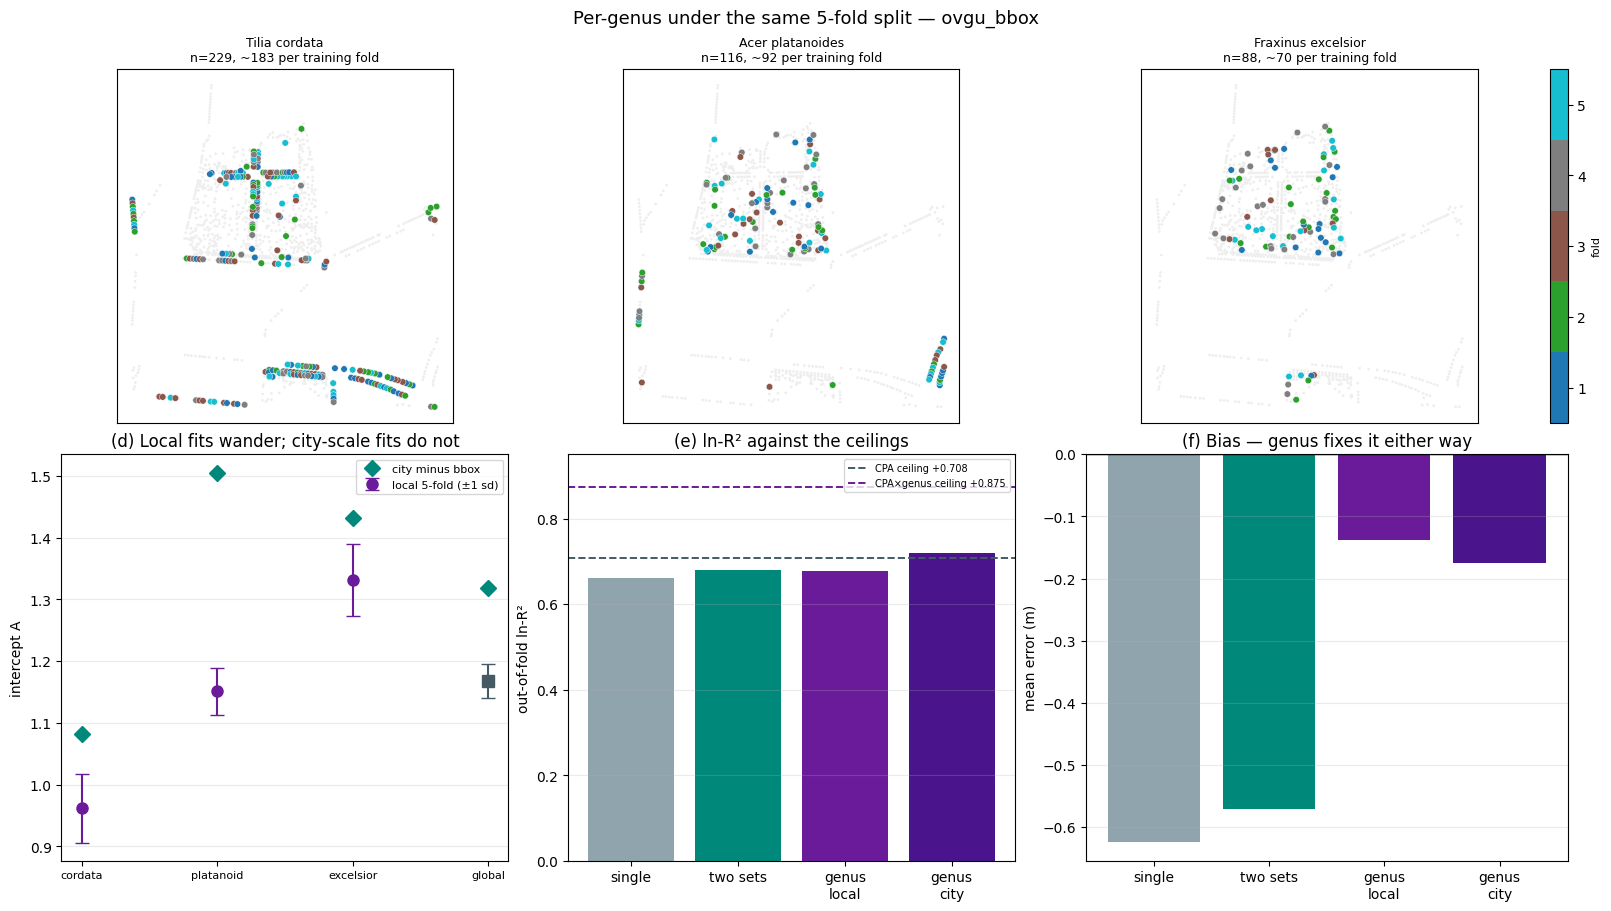

In [23]:
fig = plt.figure(figsize=(16, 9), constrained_layout=True)
gs = fig.add_gridspec(2, 4, height_ratios=[1, 1.15], width_ratios=[1, 1, 1, .04])
SHOW = list(top_genera.index[:3])

# top row: fold membership for the three commonest genera, same folds as sections 4 and 7
cmapf = plt.get_cmap("tab10", N_FOLDS)
xy_all = np.c_[trees.geometry.x, trees.geometry.y]
for j, g in enumerate(SHOW):
    a = fig.add_subplot(gs[0, j])
    m = (trees["genus"] == g).to_numpy()
    a.scatter(*xy_all[~m].T, s=4, c="#eeeeee", edgecolors="none")
    sc = a.scatter(*xy_all[m].T, s=22, c=fold_of[m], cmap=cmapf, vmin=.5, vmax=N_FOLDS + .5,
                   edgecolors="white", linewidth=.3)
    a.set_title(f"{g}\nn={m.sum()}, ~{int(m.sum()*0.8)} per training fold", fontsize=9)
    a.set_aspect("equal"); a.set_xticks([]); a.set_yticks([]); a.grid(alpha=.2)
cax = fig.add_subplot(gs[0, 3])
fig.colorbar(sc, cax=cax, ticks=range(1, N_FOLDS + 1)).set_label("fold", fontsize=8)

# bottom left: how much the locally fitted coefficients move between folds
a = fig.add_subplot(gs[1, 0])
for j, g in enumerate(SHOW):
    if f"A·{g}" not in gl:
        continue
    a.errorbar(j, gl[f"A·{g}"].mean(), yerr=gl[f"A·{g}"].std(), fmt="o", ms=8, capsize=5,
               color="#6a1b9a", label="local 5-fold (±1 sd)" if j == 0 else None)
    if g in prof_holdout:
        a.plot(j, prof_holdout[g][0], "D", ms=8, color="#00897b",
               label="city minus bbox" if j == 0 else None)
a.errorbar(len(SHOW), gl["A_global"].mean(), yerr=gl["A_global"].std(), fmt="s", ms=8, capsize=5, color="#455a64")
a.plot(len(SHOW), A_glob, "D", ms=8, color="#00897b")
a.set_xticks(range(len(SHOW) + 1), [g.split()[1][:9] for g in SHOW] + ["global"], fontsize=8)
a.set(ylabel="intercept A", title="(d) Local fits wander; city-scale fits do not")
a.legend(fontsize=8); a.grid(alpha=.25, axis="y")

# bottom middle: the four models side by side
a = fig.add_subplot(gs[1, 1])
nm = ["single", "two sets", "genus\nlocal", "genus\ncity"]
a.bar(nm, cmp_all["r2_ln"], color=["#90a4ae", "#00897b", "#6a1b9a", "#4a148c"])
for v, c, lab in [(noise_ceiling(trees["cpa_m2"], trees["Baumhoehe"]), "#455a64", "CPA ceiling"),
                  (noise_ceiling(trees["cpa_m2"], trees["Baumhoehe"], by=trees["genus"].to_numpy()),
                   "#6a1b9a", "CPA×genus ceiling")]:
    a.axhline(v, ls="--", lw=1.4, color=c, label=f"{lab} {v:+.3f}")
a.set(ylabel="out-of-fold ln-R²", ylim=(0, .95), title="(e) ln-R² against the ceilings")
a.legend(fontsize=7); a.grid(alpha=.25, axis="y")

# bottom right: bias, which is where genus pays regardless of where it was fitted
a = fig.add_subplot(gs[1, 2:])
a.bar(nm, cmp_all["bias_m"], color=["#90a4ae", "#00897b", "#6a1b9a", "#4a148c"])
a.axhline(0, color="k", lw=1)
a.set(ylabel="mean error (m)", title="(f) Bias — genus fixes it either way")
a.grid(alpha=.25, axis="y")

fig.suptitle("Per-genus under the same 5-fold split — ovgu_bbox", fontsize=13)
plt.show()

**What the comparison shows.** Fitted locally under the same folds, per-genus still beats both the
single set and two sets on **bias** — it is the least biased of the four models — but its ln-R² lands
below the city-scale version. Two reasons, both visible above: local coverage is only ~59 % against
86 % for the city-fitted profiles, and panel (d) shows the local coefficients wandering between folds
where the city-scale ones are effectively fixed.

So the genus *effect* is real and recoverable from 1,045 trees, but stable genus *coefficients* are
not. That is an argument for keeping `ALLOMETRIC_PROFILES` fitted citywide and validating them here,
which is exactly what §8 did — not for refitting them per study area.